# Ice Recrystallization Inhibition (Two Critical Radii)

This notebook shows a minimal run of the IRI model with:
- one melting critical radius,
- one freezing critical radius,
- a stay region between them where growth velocity is zero.

## Governing equations

We evolve the particle-size distribution $f(R,t)$ and bulk concentration $c_{\mathrm{bulk}}(t)$ using:

$$
\frac{\partial f}{\partial t}+\frac{\partial}{\partial R}\left(f\,v_R\right)=0
$$

$$
\frac{d c_{\mathrm{bulk}}}{dt}=-4\pi\rho_{\mathrm{ice}}\int_0^{\infty}R^2 v_R f\,dR
$$

Define two critical radii:

$$
r_{c,\mathrm{melt}}=\frac{\alpha}{c_{\mathrm{bulk}}-c_{\mathrm{flat}}+k_mL^{-2}},
\qquad
r_{c,\mathrm{freeze}}=\frac{\alpha}{c_{\mathrm{bulk}}-c_{\mathrm{flat}}-k_fL^{-2}}
$$

Then $v_R=dR/dt$ is piecewise (three regions):

$$
v_R(R,t)=\begin{cases}
\dfrac{D}{R\rho_{\mathrm{ice}}}\left(c_{\mathrm{bulk}}-c_{\mathrm{flat}}-\dfrac{\alpha}{R}+k_mL^{-2}\right), & R<r_{c,\mathrm{melt}} \quad (\text{small-}R\ \text{branch})\\[6pt]
0, & r_{c,\mathrm{melt}}\le R\le r_{c,\mathrm{freeze}} \quad (\text{stay})\\[6pt]
\dfrac{D}{R\rho_{\mathrm{ice}}}\left(c_{\mathrm{bulk}}-c_{\mathrm{flat}}-\dfrac{\alpha}{R}-k_fL^{-2}\right), & R>r_{c,\mathrm{freeze}} \quad (\text{large-}R\ \text{branch})
\end{cases}
$$

For the stay region to be non-empty, we need $r_{c,\mathrm{melt}} < r_{c,\mathrm{freeze}}$. If these radii overlap or reverse order, the zero-velocity window shrinks or vanishes.

### Parameter definitions

$$
c_{\mathrm{flat}}=\exp\!\left(-\frac{\Delta h}{T_{\mathrm{eq}}}\frac{\Delta T}{RT}\right)\,C_{\mathrm{water}}
$$

where $C_{\mathrm{water}}=55\,\mathrm{mol/L}$ (then converted to $\mathrm{number}/\mu\mathrm{m}^3$ in code).

$$
\alpha=\frac{2\gamma}{RT}\,v_m\,c_{\mathrm{flat}}
$$

with $\gamma$ in $\mathrm{mJ}/\mathrm{m}^2$ (converted to $\mathrm{J}/\mathrm{m}^2$ in code) and $v_m$ in $\mathrm{cm}^3/\mathrm{mol}$.

$$
k_f=\frac{\alpha P_f}{2},\qquad k_m=\frac{\alpha P_m}{2}
$$

where $P_f$ and $P_m$ are effective AFP perimeters for freezing and melting, respectively.

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import iri_model
importlib.reload(iri_model)
from iri_model import run_simulation, critical_radii

In [10]:
# Parameter derivation (explicit formulas + units)

# Unit conversion: mol/L -> number/µm^3
NA = 6.02e23                         # [molecule/mol]
molL_to_num_per_um3 = NA / 1e15      # [number/µm^3]
print(f"1 mol/L = {molL_to_num_per_um3:.3e} number/µm^3")

# Physical constants and chosen conditions
delT = 5.0                            # [K], supercooling
T_eq = 273.0                          # [K]
T = 268.0                             # [K]
R_gas = 8.314                         # [J/(mol·K)]
Dh = 6000.0                           # [J/mol] molar enthalpy change for ice-water phase transition
gamma = 30.0                          # [mJ/m^2] ice-water interfacial energy
Pm = 0.002                            # [µm] perimeter of adsorbed AFP when melting
Pf = 0.01                             # [µm] perimeter of adsorbed AFP when freezing
L = 0.5                               # [µm] AFP separation length (characteristic length)

# If you start from water number density n_water = 33 [#/nm^3],
# convert to molar volume v_m [cm^3/mol]: v_m = N_A / n_water
n_water_nm3 = 33.0                    # [#/nm^3]
n_water_cm3 = n_water_nm3 * 1e21      # [#/cm^3] (1 cm^3 = 1e21 nm^3)
v_m = NA / n_water_cm3                # [cm^3/mol] ~ 18.2 for water
print(f"v_m from 33 #/nm^3 = {v_m:.3f} cm^3/mol")

# Diffusivity (from model assumption)
D = 1120.0                            # [µm^2/s]

# rho_ice calculation from density and molecular conversion
# rho_ice = (910 g/L) / (18 g/mol) * (6.02e23 molecule/mol) / (1e15 µm^3/L)
rho_ice = 910/18*1000*6.02*100_000    # [number/µm^3]

# Flat-interface concentration
# c_flat = exp(-(Dh/T_eq)*(delT/(R*T))) * (55 mol/L) * conversion
c_flat = np.exp(-Dh/T_eq*delT/R_gas/T) * 55.0 * molL_to_num_per_um3  # [number/µm^3]

# Gibbs-Thomson-type coefficient
# alpha = 2*gamma/(R*T) * v_m * c_flat with gamma in [mJ/m^2], v_m in [cm^3/mol], c_flat in [number/µm^3]
alpha = 2.0 * (gamma * 1e-3) / (R_gas * T) * v_m * c_flat   # [number/µm^2]

# Adsorption-length terms
invL2 = 0.0 if np.isinf(L) else 1.0 / (L**2)   # [1/µm^2], so L=inf -> invL2=0
kf = alpha * Pf / 2                              # [number/µm]
km = alpha * Pm / 2                              # [number/µm]

print(f"rho_ice = {rho_ice:.4e} [number/µm^3]")
print(f"c_flat  = {c_flat:.4e} [number/µm^3]")
print(f"alpha   = {alpha:.4e} [number/µm^2]")
print(f"kf, km  = {kf:.4e}, {km:.4e} [number/µm]")
print(f"invL2   = {invL2:.4e} [1/µm^2]")

1 mol/L = 6.020e+08 number/µm^3
v_m from 33 #/nm^3 = 18.242 cm^3/mol
rho_ice = 3.0434e+10 [number/µm^3]
c_flat  = 3.1517e+10 [number/µm^3]
alpha   = 1.5482e+07 [number/µm^2]
kf, km  = 7.7410e+04, 1.5482e+04 [number/µm]
invL2   = 4.0000e+00 [1/µm^2]


In [11]:
# Radius grid (micrometer)
R = np.linspace(0.1, 40.0, 800)

# Initial particle size distribution (Gaussian)
# f(R) unit: 1/µm^4 so that ∫f(R)dR gives number density [1/µm^3]
n = 100
V = 170**3  # [µm^3]
mean_R = 10.0
std_R = 2.0
A = n / (std_R * V * np.sqrt(2.0 * np.pi))
f_init = A * np.exp(-0.5 * ((R - mean_R) / std_R) ** 2)

# Initial concentration [number/µm^3]
c_bulk_init = (c_flat + alpha / mean_R + kf * invL2) * 1.001

# Model parameters (computed in previous cell)
params = {
    "D": D,
    "rho_ice": rho_ice,
    "c_flat": c_flat,
    "alpha": alpha,
    "k_f": kf,
    "k_m": km,
    "invL2": invL2,
    "time_unit": "ms",  # default unit is now ms
    # "flux_scheme": "gradient"
}



R_melt0, R_freeze0 = critical_radii(c_bulk_init, params)
print(f"Initial melt critical radius:   {R_melt0:.3f} µm")
print(f"Initial freeze critical radius: {R_freeze0:.3f} µm")

Initial melt critical radius:   0.463 µm
Initial freeze critical radius: 0.468 µm


In [12]:
# Run simulation (milliseconds)
t_eval = np.linspace(0.0, 3600.0 * 1000.0, 240)

# Try: "BDF", "Radau", or "LSODA"
solver_method = "BDF"
params["solver_method"] = solver_method
params["solver_rtol"] = 1e-8
params["solver_atol"] = 1e-11

sol = run_simulation(
    f_init=f_init,
    c_bulk_init=c_bulk_init,
    R=R,
    t_span=(0.0, 3600.0 * 1000.0),
    t_eval=t_eval,
    params=params,
    mode="double",  # uses two critical radii with stay region
    show_progress=True,
    progress_chunks=40,
 )

f_final = sol.y[:-1, -1]
c_bulk_final = sol.y[-1, -1]
print(f"Solver: {solver_method}")
print(f"Solver success: {sol.success}")
print(f"Final c_bulk: {c_bulk_final:.4e}")

Simulation progress: 100%
Solver: BDF
Solver success: True
Final c_bulk: 3.1518e+10


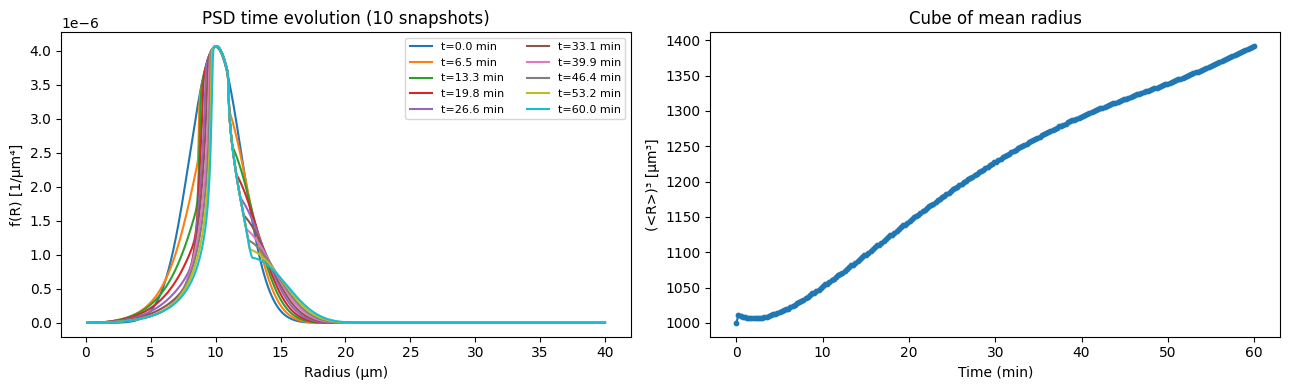

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

time_unit = str(params.get("time_unit", "ms")).lower()
if time_unit == "ms":
    time_to_min = 60000.0
elif time_unit == "s":
    time_to_min = 60.0
else:
    raise ValueError("params['time_unit'] must be 'ms' or 's'.")

# Plot ~10 PSD snapshots across time
n_snapshots = 10
snapshot_idx = np.unique(np.linspace(0, len(sol.t) - 1, n_snapshots, dtype=int))

for idx in snapshot_idx:
    t_min = sol.t[idx] / time_to_min
    axes[0].plot(R, sol.y[:-1, idx], label=f"t={t_min:.1f} min")

axes[0].set_xlabel("Radius (µm)")
axes[0].set_ylabel("f(R) [1/µm⁴]")
axes[0].set_title("PSD time evolution (10 snapshots)")
axes[0].legend(fontsize=8, ncol=2)

# Compute (<R>)^3 over time from PSD snapshots
f_list = sol.y[:-1, :].T
average_rcube = np.array([
    (np.trapezoid(R * f_t, R) / np.trapezoid(f_t, R)) ** 3
    for f_t in f_list
])

axes[1].plot(sol.t / time_to_min, average_rcube)
axes[1].scatter(sol.t / time_to_min, average_rcube, s=10)
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("(<R>)³ [µm³]")
axes[1].set_title("Cube of mean radius")

plt.tight_layout()
plt.show()

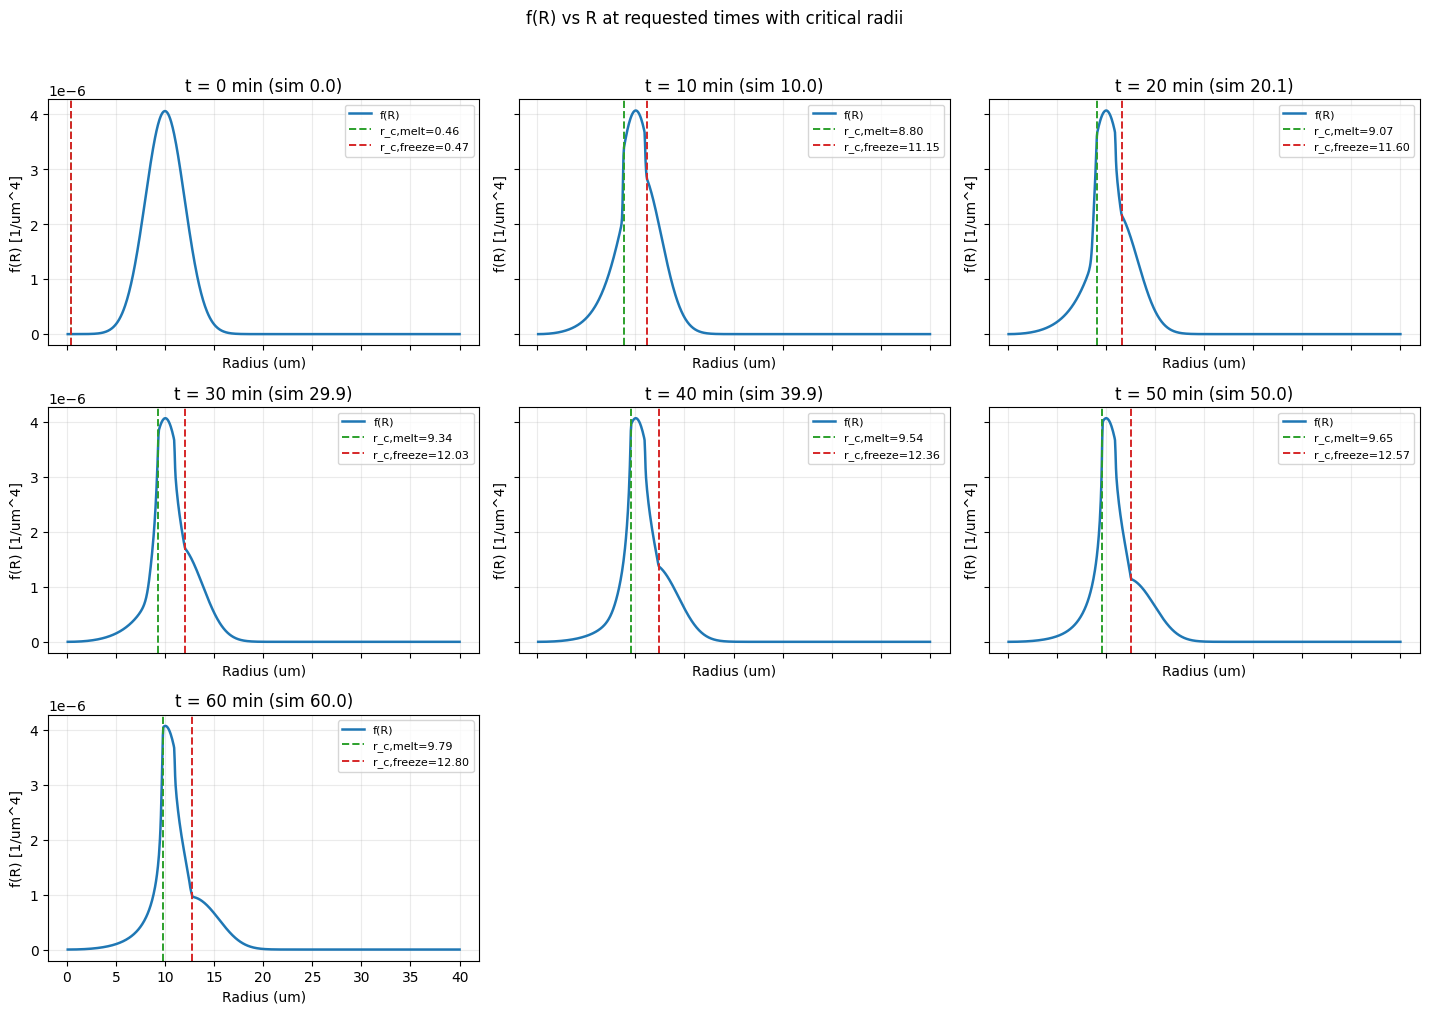

In [16]:
# f(R) vs R with one subplot per requested time: 0,10,...,60 min
target_times_min = np.arange(0, 61, 10, dtype=float)
max_time_min = sol.t[-1] / time_to_min
target_times_min = target_times_min[target_times_min <= max_time_min + 1e-12]

if target_times_min.size == 0:
    raise ValueError("No requested snapshot times are within the simulated time range.")

# Use nearest simulated index to each requested time.
snapshot_idx = np.array([
    np.argmin(np.abs(sol.t - t_min * time_to_min))
    for t_min in target_times_min
], dtype=int)

n_cols = 3
n_rows = int(np.ceil(len(target_times_min) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.3 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for i, (t_req_min, idx) in enumerate(zip(target_times_min, snapshot_idx)):
    t_actual_min = sol.t[idx] / time_to_min
    c_bulk_t = sol.y[-1, idx]
    r_melt_t, r_freeze_t = critical_radii(c_bulk_t, params)

    ax = axes[i]
    ax.plot(R, sol.y[:-1, idx], lw=1.8, label="f(R)")

    if np.isfinite(r_melt_t):
        ax.axvline(r_melt_t, color="tab:green", ls="--", lw=1.4, label=f"r_c,melt={r_melt_t:.2f}")
    if np.isfinite(r_freeze_t):
        ax.axvline(r_freeze_t, color="tab:red", ls="--", lw=1.4, label=f"r_c,freeze={r_freeze_t:.2f}")

    ax.set_title(f"t = {t_req_min:.0f} min (sim {t_actual_min:.1f})")
    ax.set_xlabel("Radius (um)")
    ax.set_ylabel("f(R) [1/um^4]")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

# Hide any unused subplot axes in the grid.
for j in range(len(target_times_min), len(axes)):
    axes[j].axis("off")

fig.suptitle("f(R) vs R at requested times with critical radii", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Save f(R) snapshots and corresponding critical radii for t = 0,10,...,60 min
import os

output_dir = os.path.join("results", "fR_snapshots_0to60min")
os.makedirs(output_dir, exist_ok=True)

target_times_min = np.arange(0, 61, 10, dtype=float)
max_time_min = sol.t[-1] / time_to_min
target_times_min = target_times_min[target_times_min <= max_time_min + 1e-12]

if target_times_min.size == 0:
    raise ValueError("No requested snapshot times are within the simulated time range.")

snapshot_idx = np.array([
    np.argmin(np.abs(sol.t - t_min * time_to_min))
    for t_min in target_times_min
], dtype=int)

# Build one table with R plus f(R) columns at each requested time.
fR_table = np.column_stack([R] + [sol.y[:-1, idx] for idx in snapshot_idx])
header_cols = ["R_um"] + [f"f_t{int(t_req)}min" for t_req in target_times_min]
np.savetxt(
    os.path.join(output_dir, "fR_snapshots_0to60min.csv"),
    fR_table,
    delimiter=",",
    header=",".join(header_cols),
    comments="",
)

# Save critical radii at each requested time in a separate table.
rc_rows = []
for t_req_min, idx in zip(target_times_min, snapshot_idx):
    t_actual_min = sol.t[idx] / time_to_min
    c_bulk_t = sol.y[-1, idx]
    r_melt_t, r_freeze_t = critical_radii(c_bulk_t, params)
    rc_rows.append([t_req_min, t_actual_min, c_bulk_t, r_melt_t, r_freeze_t])

rc_array = np.array(rc_rows, dtype=float)
np.savetxt(
    os.path.join(output_dir, "critical_radii_0to60min.csv"),
    rc_array,
    delimiter=",",
    header="t_requested_min,t_sim_min,c_bulk,r_c_melt_um,r_c_freeze_um",
    comments="",
)

print(f"Saved files in: {output_dir}")
print(" - fR_snapshots_0to60min.csv")
print(" - critical_radii_0to60min.csv")

In [ ]:
tt_array = sol.t / time_to_min
rcube_array = average_rcube

# keep only t >= 10 min first
mask_10min = tt_array >= 10.0
tt_array = tt_array[mask_10min]
rcube_array = rcube_array[mask_10min]

slopes_dict = {}
slope, intercept = np.polyfit(tt_array[2:], rcube_array[2:], 1)
slopes_dict[invL2] = slope  # Store the slope for the current invL2

print(f"k (slope) = {slope:.10f} µm^3/min")
print(f"intercept = {intercept:.10f} µm^3")
print(f"stored in slopes_dict[{invL2}] = {slopes_dict[invL2]:.10f}")

k (slope) = 12.9604227684 µm^3/min
intercept = 961.2377955223 µm^3
stored in slopes_dict[1.0] = 12.9604227684



=== Sweep simulation 1/16: km=0.25, kf=0.25 ===
Simulation progress: 100%
Completed 1/16: slope=15.9073 µm^3/min

=== Sweep simulation 2/16: km=0.25, kf=0.5 ===
Simulation progress: 100%
Completed 2/16: slope=14.9404 µm^3/min

=== Sweep simulation 3/16: km=0.25, kf=1.0 ===
Simulation progress: 100%
Completed 3/16: slope=13.2874 µm^3/min

=== Sweep simulation 4/16: km=0.25, kf=2.0 ===
Simulation progress: 100%
Completed 4/16: slope=10.8403 µm^3/min

=== Sweep simulation 5/16: km=0.5, kf=0.25 ===
Simulation progress: 100%
Completed 5/16: slope=14.9403 µm^3/min

=== Sweep simulation 6/16: km=0.5, kf=0.5 ===
Simulation progress: 100%
Completed 6/16: slope=14.1028 µm^3/min

=== Sweep simulation 7/16: km=0.5, kf=1.0 ===
Simulation progress: 100%
Completed 7/16: slope=12.6109 µm^3/min

=== Sweep simulation 8/16: km=0.5, kf=2.0 ===
Simulation progress: 100%
Completed 8/16: slope=10.3204 µm^3/min

=== Sweep simulation 9/16: km=1.0, kf=0.25 ===
Simulation progress: 100%
Completed 9/16: slope=13

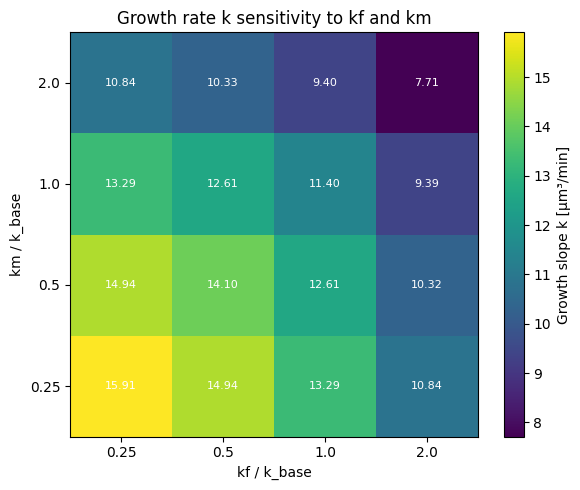

In [10]:
# Sensitivity sweep: vary k_f and k_m relative to k_base = alpha * Pf / 2
multipliers = [0.25, 0.5, 1.0, 2.0]
k_base = alpha * Pf / 2

t_eval_sweep = np.linspace(0.0, 3600.0 * 1000.0, 120)

slopes_grid = np.full((len(multipliers), len(multipliers)), np.nan)
intercepts_grid = np.full((len(multipliers), len(multipliers)), np.nan)

total_sims = len(multipliers) * len(multipliers)
sim_idx = 0

for i_km, km_mult in enumerate(multipliers):
    for j_kf, kf_mult in enumerate(multipliers):
        sim_idx += 1
        kf_test = k_base * kf_mult
        km_test = k_base * km_mult

        print(f"\n=== Sweep simulation {sim_idx}/{total_sims}: km={km_mult}, kf={kf_mult} ===")

        params_test = dict(params)
        params_test["k_f"] = kf_test
        params_test["k_m"] = km_test
        params_test["solver_method"] = "BDF"
        params_test["solver_rtol"] = 1e-5
        params_test["solver_atol"] = 1e-8

        try:
            sol_test = run_simulation(
                f_init=f_init,
                c_bulk_init=c_bulk_init,
                R=R,
                t_span=(0.0, 3600.0 * 1000.0),
                t_eval=t_eval_sweep,
                params=params_test,
                mode="double",
                show_progress=True,
                progress_chunks=20,
            )
        except Exception as err:
            print(f"Simulation {sim_idx}/{total_sims} failed with error: {err}")
            continue

        if not sol_test.success:
            print(f"Simulation {sim_idx}/{total_sims} did not converge: {sol_test.message}")
            continue

        f_list_test = sol_test.y[:-1, :].T
        rcube_array = np.array([
            (np.trapezoid(R * f_t, R) / np.trapezoid(f_t, R)) ** 3
            for f_t in f_list_test
        ])
        tt_array = sol_test.t / time_to_min

        mask_10min = tt_array >= 10.0
        tt_fit = tt_array[mask_10min]
        rcube_fit = rcube_array[mask_10min]

        if len(tt_fit) <= 2:
            print(f"Simulation {sim_idx}/{total_sims} skipped: insufficient points after 10 min.")
            continue

        slope, intercept = np.polyfit(tt_fit[2:], rcube_fit[2:], 1)
        slopes_grid[i_km, j_kf] = slope
        intercepts_grid[i_km, j_kf] = intercept
        print(f"Completed {sim_idx}/{total_sims}: slope={slope:.4f} µm^3/min")

print("\nk_base =", k_base)
print("Rows = km multiplier, Cols = kf multiplier")
print("Growth slope k [µm^3/min]:")
print(slopes_grid)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(slopes_grid, origin="lower", cmap="viridis", aspect="auto")

ax.set_xticks(range(len(multipliers)))
ax.set_xticklabels(multipliers)
ax.set_yticks(range(len(multipliers)))
ax.set_yticklabels(multipliers)
ax.set_xlabel("kf / k_base")
ax.set_ylabel("km / k_base")
ax.set_title("Growth rate k sensitivity to kf and km")

for i in range(len(multipliers)):
    for j in range(len(multipliers)):
        val = slopes_grid[i, j]
        label = "nan" if np.isnan(val) else f"{val:.2f}"
        ax.text(j, i, label, ha="center", va="center", color="white", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Growth slope k [µm³/min]")

plt.tight_layout()
plt.show()